<a href="https://colab.research.google.com/github/aryansoni200620-alt/DSA_LeetCode_Solutions/blob/main/Internship_project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fish Weight Prediction using Machine Learning
## Objective
The objective of this project is to build a Predictive Model using **Multiple Linear Regression** to estimate the weight of a fish based on its physical characteristics (such as species, height, width, and various length measurements).

### Dataset Attributes:
* **Species:** Species name of the fish
* **Weight:** Weight of the fish (in grams) - *Target Variable*
* **Length1:** Vertical length (in cm)
* **Length2:** Diagonal length (in cm)
* **Length3:** Cross length (in cm)
* **Height:** Height (in cm)
* **Width:** Diagonal width (in cm)
*

In [ ]:
# Step 1: Import necessary libraries
import pandas as pd

# Step 2: Load the dataset from the repository
fish = pd.read_csv('https://github.com/ybifoundation/Dataset/raw/main/Fish.csv')


In [ ]:
fish.head()

,Category,Species,Weight,Height,Width,Length1,Length2,Length3
0,1,Bream,242.0,11.5200,4.0200,23.2,25.4,30.0
1,1,Bream,290.0,12.4800,4.3056,24.0,26.3,31.2
2,1,Bream,340.0,12.3778,4.6961,23.9,26.5,31.1
3,1,Bream,363.0,12.7300,4.4555,26.3,29.0,33.5
4,1,Bream,430.0,12.4440,5.1340,26.5,29.0,34.0


In [ ]:
fish.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Category  159 non-null    int64  
 1   Species   159 non-null    object 
 2   Weight    159 non-null    float64
 3   Height    159 non-null    float64
 4   Width     159 non-null    float64
 5   Length1   159 non-null    float64
 6   Length2   159 non-null    float64
 7   Length3   159 non-null    float64
dtypes: float64(6), int64(1), object(1)
memory usage: 10.1+ KB


In [ ]:
fish.describe()

,Category,Weight,Height,Width,Length1,Length2,Length3
count,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,3.264151,398.326415,8.970994,4.417486,26.247170,28.415723,31.227044
std,1.704249,357.978317,4.286208,1.685804,9.996441,10.716328,11.610246
min,1.000000,0.000000,1.728400,1.047600,7.500000,8.400000,8.800000
25%,2.000000,120.000000,5.944800,3.385650,19.050000,21.000000,23.150000
50%,3.000000,273.000000,7.786000,4.248500,25.200000,27.300000,29.400000
75%,4.500000,650.000000,12.365900,5.584500,32.700000,35.500000,39.650000
max,7.000000,1650.000000,18.957000,8.142000,59.000000,63.400000,68.000000


## Step 3: Define Target (y) and Features (X)
To train our machine learning model, we need to separate our dataset into:
1. **Target Variable (y):** The variable we want to predict (`Weight`).
2. **Feature Variables (X):** The independent attributes used to make the prediction (`Category`, `Height`, `Width`, `Length1`, `Length2`, `Length3`).

We will also split the data into **Training (70%)** and **Testing (30%)** sets. This ensures we can evaluate our model on unseen data to test its real-world accuracy.


In [ ]:
# Verify columns first
print(fish.columns)

# Define target variable y
y = fish['Weight']

# Define feature variables X
X = fish[['Category', 'Height', 'Width', 'Length1', 'Length2', 'Length3']]


Index(['Category', 'Species', 'Weight', 'Height', 'Width', 'Length1',
       'Length2', 'Length3'],
      dtype='object')


In [ ]:
# Import train_test_split from sklearn
from sklearn.model_selection import train_test_split

# Split the data into 70% training and 30% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=2529)

# Verify the shape of our splits
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((111, 6), (48, 6), (111,), (48,))

## Step 5 & 6: Model Selection and Training
We are using **Multiple Linear Regression** because we have multiple independent features trying to predict a continuous numerical value (Weight).

The model will find the best-fitting line by calculating:
* **Intercept:** The baseline weight value when all features are zero.
* **Coefficients:** The weight/importance given to each individual feature (Height, Width, etc.).
*

In [ ]:
# Import Linear Regression from sklearn
from sklearn.linear_model import LinearRegression

# Initialize the model
model = LinearRegression()

# Train (fit) the model on our training data
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Display the Intercept
print("Intercept:", model.intercept_)

# Display the Coefficients for each feature
print("Coefficients:", model.coef_)


Intercept: -684.4235918478537
Coefficients: [ 35.19634977  52.19372157 -37.13869125  11.2218449   78.11233002
 -59.11783139]


In [ ]:
# Predict the weights for the test dataset
y_pred = model.predict(X_test)

# Display the predicted values
y_pred

array([ 475.93351307,  525.81910195,   77.63275849,  881.10235121,
        160.9685664 ,  255.94371856,  361.87029932,  358.87068094,
        499.83411068, -150.07834151, -115.91810869,  428.65470115,
        114.67533404,  812.51385122,  586.5071178 ,  273.38510858,
        579.63900729,  225.18126845,  639.26068037,   85.00820599,
        136.92159041,  -87.7778087 ,  629.97231046,  732.63097812,
        859.8720695 , -166.76928607,  342.04209934,  722.92198147,
        321.44827179,  787.98248357,  486.93194673,  541.89982795,
        376.74813045,  624.81211202, -170.11945033,  917.76513801,
        792.26439518,  -21.15655005,  300.24921659,  914.07325473,
        621.05636286,  934.17373986,  676.85479574,  653.92304403,
        615.51226767,  336.61090622,  505.75519147,  -33.53283763])

## Step 8: Model Evaluation
To evaluate how well our model performs on unseen data, we use two key metrics:
1. **Mean Absolute Error (MAE):** The average absolute difference between the actual fish weights and the predicted fish weights. Lower is better.
2. **R-squared ($R^2$) Score:** The coefficient of determination. It tells us what percentage of the variance in fish weight is explained by our features. A score closer to 1.0 indicates a highly accurate model.
3.

In [ ]:
# Import evaluation metrics from sklearn
from sklearn.metrics import mean_absolute_error, r2_score

# Calculate Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

# Calculate R-squared Score
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"R-squared Score: {r2:.4f}")

Mean Absolute Error: 99.59
R-squared Score: 0.8398


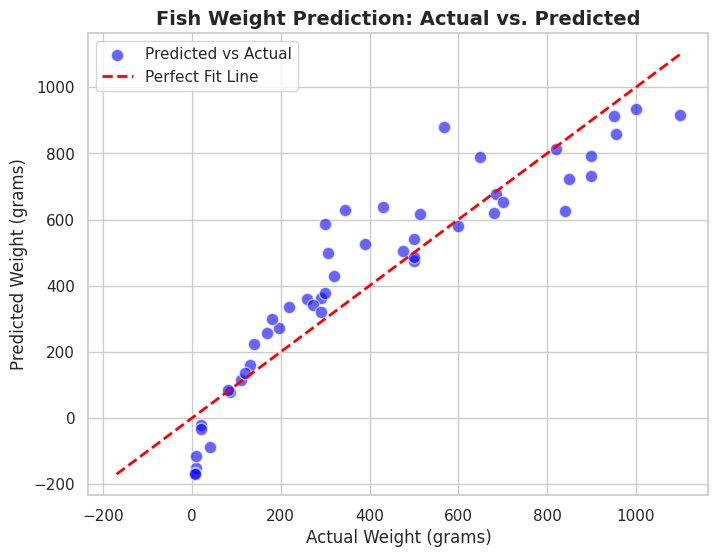

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

# Create the plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, edgecolors='w', s=80, label='Predicted vs Actual')

# Add a perfect fit diagonal line
max_val = max(max(y_test), max(y_pred))
min_val = min(min(y_test), min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Fit Line')

# Labels and Title
plt.xlabel('Actual Weight (grams)', fontsize=12)
plt.ylabel('Predicted Weight (grams)', fontsize=12)
plt.title('Fish Weight Prediction: Actual vs. Predicted', fontsize=14, fontweight='bold')
plt.legend()

# Show the plot
plt.show()
